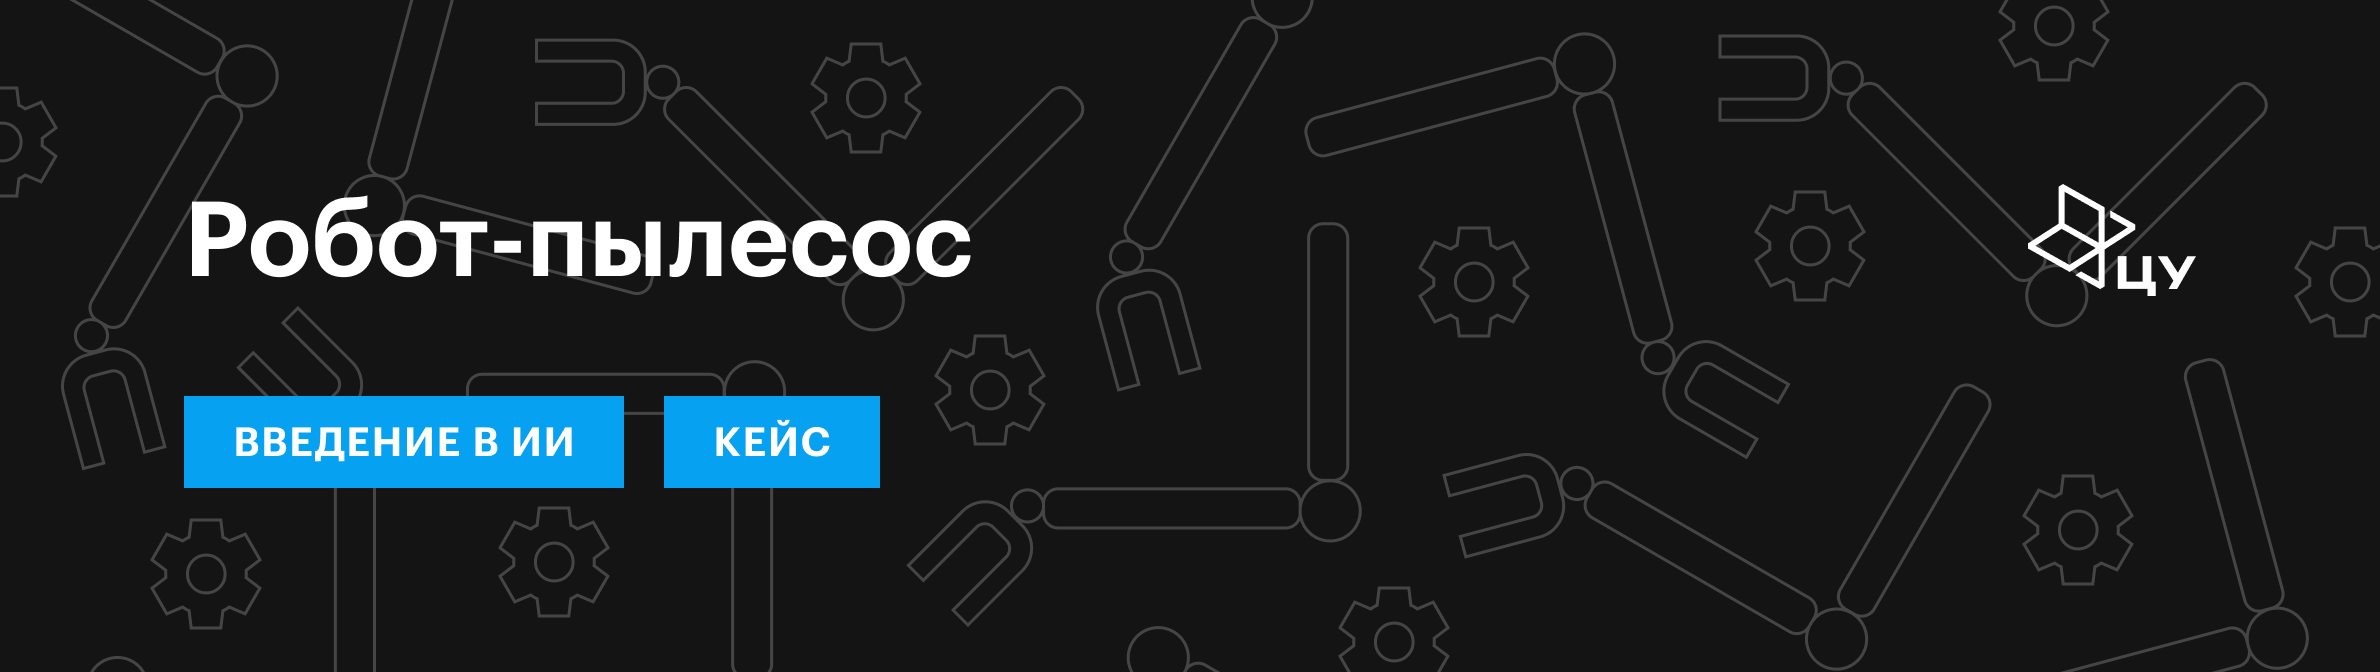

# Описание

Гена — ленивый робот-пылесос с искусственным интеллектом (ну, почти).  Гена быстро сориентировался в новой квартире и смекнул: если просто кататься туда-сюда, уборка никогда не кончится! Хозяин в бешенстве, ведь в комнате всего три кучки мусора.

Всё отягчается тем, что посредине дрыхнет кот Васька — главный хранитель ковра. Если Гена по глупости заедет на ковёр, кот проснётся и устроит апокалипсис: обои в клочья, цветы перевёрнуты, уборка провалена.

Ваша задача — подобрать Гене награду и обучить его так, чтобы Гена наконец начал убираться, обходя кота стороной, и доказать, что даже ленивый пылесос способен на трудовой подвиг. Дерзайте!

Требования к решению:

Поскольку это учебный проект, вводятся следующие технические ограничения:

* Использование ИИ: Писать код с помощью LLM запрешено

* Обучаемость: запрещено использовать детерминированную политику "Если мы в клетке X, сдвинуться в клетку Y", которую вы напишите вручную — ваш код должен задавать **процедуру обучения** агента, а не сразу правильный ответ

* Воспроизводимость: Весь код должен выполняться последовательно. Обязательно фиксируйте random_seed, если он у вас есть, а также сохраняйте веса моделей и удаляйте лишние ячейки.

Система оценивания:

* Работа с наградой [1 балл]: Оценка ставится в соответствии с тем, насколько качественно была произведена работа с наградой. Не обязательно делать награду навороченной ради навороченности, но все ваши решения в дизайне награды должны быть понятны и смотивированы

* Работа с агентом [7 баллов]: Оценка ставится за степень "раскрутки" алгоритма для агента и итоговое качество. При этом не обязательно выбирать самый сложный алгоритм — достаточно качественно поработать (расписать, модифицировать, разобрать) любой понравившийся и подходящий алгоритм

* Оформление [2 балла]: Хочется, чтобы написанный код читался, как хорошая книга. Для этого мы добавляем баллы за оформление — они выше, если в коде появляются визуализации, комментарии к коду и сопроводительный текст, и ниже за их отсутствие

# Постановка задачи

Среда, с которой мы будем работать, будет представлять комнату в виде сетки размера 8x8. Синим кружочком мы будем обозначать положение робота-пылесоса, красными квадратами — мусор, который надо собрать, а жёлтым квадратом — злобного кота Ваську

### Описание среды

In [ ]:
# Ячейка 1: Установка и импорты
!pip install gymnasium numpy matplotlib -q

import gymnasium as gym
from gymnasium import spaces
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
from enum import IntEnum
from IPython.display import HTML, clear_output
import matplotlib.animation as animation
from IPython.display import HTML, display, clear_output

In [ ]:
class LazyRobotEnv(gym.Env):
    """
    Комната 5x5 с 3 кучками мусора и спящим котом (2,2).
    Если робот заезжает на клетку с котом – эпизод досрочно завершается (truncated).
    Награда по умолчанию +1000 за любое действие.
    """
    metadata = {"render_modes": ["rgb_array"], "render_fps": 4}

    def __init__(self, render_mode=None):
        super().__init__()
        self.size = 8
        self.dirt_positions = [(1, 1), (3, 2), (7, 3), (5, 6)]
        self.cat_pos = (4, 4)                # кот Васька – статичен
        self.max_steps = 100

        self.action_space = spaces.Discrete(4)
        self.observation_space = spaces.MultiDiscrete([5, 5, 2, 2, 2])

        self.render_mode = render_mode
        self._current_frame = None

    def get_obs(self):
        """Текущее наблюдение (используется враппером награды)."""
        return self._get_obs()

    def _get_obs(self):
        return np.array([
            self.agent_pos[0], self.agent_pos[1],
            self.dirt_status[0], self.dirt_status[1], self.dirt_status[2]
        ], dtype=np.int32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.agent_pos = [0, 0]
        self.dirt_status = [1, 1, 1, 1]
        self.steps = 0
        obs = self._get_obs()
        if self.render_mode == "rgb_array":
            self._current_frame = self._render_frame()
        return obs, {}

    def step(self, action):
        x, y = self.agent_pos
        if action == Action.UP:
            y = max(0, y - 1)
        elif action == Action.RIGHT:
            x = min(self.size - 1, x + 1)
        elif action == Action.DOWN:
            y = min(self.size - 1, y + 1)
        elif action == Action.LEFT:
            x = max(0, x - 1)
        self.agent_pos = [x, y]

        # Проверка столкновения с котом
        cat_hit = (self.agent_pos[0] == self.cat_pos[0] and
                   self.agent_pos[1] == self.cat_pos[1])

        # Уборка мусора
        for i, pos in enumerate(self.dirt_positions):
            if self.agent_pos == list(pos) and self.dirt_status[i] == 1:
                self.dirt_status[i] = 0

        # Глупая награда (будет переопределена враппером)
        reward = 1000.0
        done = all(s == 0 for s in self.dirt_status)
        self.steps += 1
        truncated = self.steps >= self.max_steps or cat_hit

        info = {
            "dirt_status": self.dirt_status.copy(),
            "cat_hit": cat_hit
        }

        obs = self._get_obs()
        if self.render_mode == "rgb_array":
            self._current_frame = self._render_frame()

        return obs, reward, done, truncated, info

    def render(self):
        if self.render_mode == "rgb_array":
            return self._current_frame
        raise NotImplementedError("Поддерживается только rgb_array")

    def _render_frame(self):
        """Отрисовка комнаты с мусором, роботом и котом."""
        fig, ax = plt.subplots(figsize=(3, 3))
        ax.set_xlim(0, self.size)
        ax.set_ylim(0, self.size)
        ax.set_xticks(np.arange(self.size))
        ax.set_yticks(np.arange(self.size))
        ax.grid(True)

        # Мусор
        for i, (dx, dy) in enumerate(self.dirt_positions):
            if self.dirt_status[i]:
                rect = Rectangle((dx, self.size - 1 - dy), 1, 1,
                                 facecolor='brown', alpha=0.7)
                ax.add_patch(rect)

        # Кот Васька
        cat_x, cat_y = self.cat_pos
        ax.add_patch(Rectangle((cat_x, self.size - 1 - cat_y), 1, 1,
                               facecolor='orange', alpha=0.9, edgecolor='black'))
        ax.text(cat_x + 0.5, self.size - 1 - cat_y + 0.5, '😾',
                ha='center', va='center', fontsize=20)

        # Робот
        ax.add_patch(Circle(
            (self.agent_pos[0] + 0.5, self.size - 1 - self.agent_pos[1] + 0.5),
            0.4, color='blue'
        ))

        ax.set_aspect('equal')
        fig.canvas.draw()
        buf = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
        img = buf.reshape(*fig.canvas.get_width_height()[::-1], 4)[..., :3]
        plt.close(fig)
        return img

### Описание действий

Действия робота-пылесоса логичны — идти вниз, вверх, влево или вправо. Для простоты и удобства мы заменили обычные коды действий удобными обозначениями через `Enum` класс — теперь вместо действия `0` можно писать `Action.UP`

In [ ]:
class Action(IntEnum):
    """Возможные действия робота."""
    UP = 0      # шаг вверх
    RIGHT = 1   # шаг вправо
    DOWN = 2    # шаг вниз
    LEFT = 3    # шаг влево

### Запуск среды

Давай содадим нашу среду, пройдём в ней вниз на одну клетку и нарисуем, что получится:

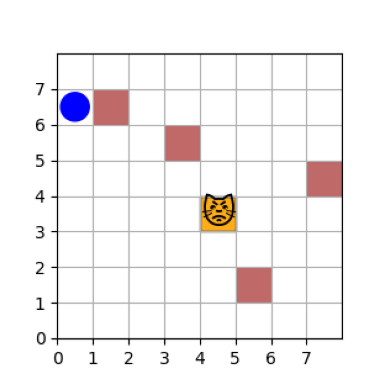

In [ ]:
# Создаём среду и включаем режим отрисовки
env = LazyRobotEnv(render_mode="rgb_array")

# Сбрасываем её (стартовая позиция)
obs, _ = env.reset()
obs, reward, done, truncated, info = env.step(Action.DOWN)

# Получаем кадр текущего состояния
frame = env.render()

# Выводим
import matplotlib.pyplot as plt
plt.imshow(frame)
plt.axis('off')
plt.show()

К сожалению, за одно действие мы не смогли решить задачу и собрать весь мусор :(

Видимо, нам всё-таки придётся прибегнуть к машинному обучению

### Награда

Для удобства тебе предоставлена обёртка для будущей функции наград — обернув ею функцию ты сможешь использовать функцию награды, предложенную ниже, для обучения

In [ ]:
class CustomRewardWrapper(gym.Wrapper):
    """
    Позволяет переопределить награду.
    reward_fn(old_obs, action, new_obs, info) -> float
    """
    def __init__(self, env, reward_fn):
        super().__init__(env)
        self.reward_fn = reward_fn

    def step(self, action):
        old_obs = self.env.get_obs()
        obs, _, done, truncated, info = self.env.step(action)
        reward = self.reward_fn(old_obs, action, obs, info)
        return obs, reward, done, truncated, info

Ниже предоставлен пример награды — пока что она имеет мало смысла, потому что каждое действие она награждает 1000 очков. Давай воспользуемся информацией о старом состоянии `old_obs` и новом состоянии `new_obs`, чтобы модифицировать её так, как тебе покажется логичным!

In [ ]:
def dummy_reward(old_obs, action, new_obs, info):
    return 1000

### Агент

Помимо среды и награды нам нужен агент. Пока что он тоже довольно глупый и выбирает действие случайно — процедуру выбора действия нам также предстоит модифицировать

In [ ]:
class DownAgent:
    """Агент, выбирающий действие случайно."""
    def get_action(self, state, training=True):
        # Пока что state игнорируется, работаем только с действиями: UP, RIGHT, DOWN, LEFT
        return Action.DOWN

Теперь у нас есть всё для обучения. Да, награда требует модификации, а агент нормального обучения, но давай запустим проверку качества уже сейчас, а заодно нарисуем траекторию движения робота-пылесоса

### Отрисовка результата

Будет здорово отрисовать анимацию прохождения комнаты роботом. Для этого опишем несколько вспомогательных функций, в устройство которых можно не вникать

In [ ]:
def evaluate(agent, num_episodes=100):
    """
    Метрика: доля успешных уборок до истечения 100 шагов и среднее число шагов.
    Использует базовую среду (без враппера награды).
    """
    env = LazyRobotEnv()
    successes = 0
    steps_list = []
    for _ in range(num_episodes):
        obs, _ = env.reset()
        done, truncated = False, False
        steps = 0
        while not (done or truncated):
            action = agent.get_action(obs, training=False)
            obs, _, done, truncated, _ = env.step(action)
            steps += 1
        if done:   # всё чисто
            successes += 1
            steps_list.append(steps)
    success_rate = successes / num_episodes
    avg_steps = np.mean(steps_list) if steps_list else float('inf')
    return success_rate, avg_steps


def run_episode_for_animation(agent):
    """Прогоняет эпизод и собирает кадры."""
    env = LazyRobotEnv(render_mode="rgb_array")
    obs, _ = env.reset()
    frames = [env.render()]
    done, truncated = False, False
    while not (done or truncated):
        action = agent.get_action(obs, training=False)
        obs, _, done, truncated, _ = env.step(action)
        frames.append(env.render())
    return frames


def show_animation(frames, fps=4):
    fig, ax = plt.subplots()
    plt.axis('off')
    im = ax.imshow(frames[0])
    def animate(i):
        im.set_data(frames[i])
        return [im]
    anim = animation.FuncAnimation(fig, animate, frames=len(frames),
                                   interval=1000/fps, blit=True)
    plt.close(fig)
    return HTML(anim.to_html5_video())

### Обучение

Этот момент настал — теперь у нас есть всё для обучения! Да, награда требует модификации, а агент нормального обучения, но давай запустим проверку качества уже сейчас, а заодно нарисуем траекторию движения робота-пылесоса

In [ ]:
env = LazyRobotEnv()
wrapped_env = CustomRewardWrapper(env, dummy_reward) # Твоя награда
agent = DownAgent() # Твой аген

In [ ]:
# Оценка бейзлайна
sr, avg = evaluate(agent)
print(f"Бейзлайн: успешных уборок {sr*100:.1f}%, среднее шагов {avg:.1f}")

# Анимация одного примера
frames = run_episode_for_animation(agent)
show_animation(frames)

Бейзлайн: успешных уборок 0.0%, среднее шагов inf


# 3. Решение

Сделаем кастомную функцию награды. За собранный мусор - будем давать большую награду, за наступление на кота, будем давать огромный штраф, за обычный шаг дадим маленький штраф ну просто потому что

In [ ]:
# Твой код
def custom_reward(old_obs, action, new_obs, info):
  reward = -1.0

  if info.get("cat_hit",False):
    return -500.0

  old_dirt_count = sum(old_obs[2:])
  new_dirt_count = sum(new_obs[2:])

  if new_dirt_count < old_dirt_count:
    reward += 100.0

  if new_dirt_count ==0:
    reward +=200.0#вес мусор убран

  return reward

Создадим Q-агента

In [ ]:
class QLearningAgent:
  def __init__(self,action_space_size = 4, lr=0.1, gamma = 0.99, epsilon = 1.0, min_epsilon = 0.05,epsilon_decay = 0.995):
    self.action_space_size = action_space_size
    self.lr = lr
    self.gamma = gamma
    self.epsilon = epsilon
    self.min_epsilon = min_epsilon
    self.epsilon_decay = epsilon_decay

    self.q_table = {}

  def _get_state_key(self,state):
    return tuple(state)

  def get_action(self,state,training = True):
    state_key = self._get_state_key(state)

    if state_key not in self.q_table:
      self.q_table[state_key] = np.zeros(self.action_space_size)

    if training and np.random.rand() < self.epsilon:
      return np.random.choice(self.action_space_size)

    return np.argmax(self.q_table[state_key])

  def update(self,state,action,reward, next_state, done):
    state_key = self._get_state_key(state)
    next_state_key = self._get_state_key(next_state)

    if state_key not in self.q_table:
      self.q_table[state_key] = np.zeros(self.action_space_size)
    if next_state_key not in self.q_table:
      self.q_table[next_state_key] = np.zeros(self.action_space_size)

    q_value = self.q_table[state_key][action]
    next_max = np.max(self.q_table[next_state_key]) if not done else 0

    self.q_table[state_key][action] = q_value+self.lr*(reward+self.gamma*next_max-q_value)

  def decay_epsilon(self):
    self.epsilon = max(self.min_epsilon, self.epsilon*self.epsilon*self.epsilon_decay)




Обучение

In [ ]:
import random

random_seed = 42
np.random.seed(random_seed)
random.seed(random_seed)

#Создаем среду и агента
base_env = LazyRobotEnv()
env = CustomRewardWrapper(base_env,custom_reward)

agent = QLearningAgent()

num_episodes = 2000

for episode in range(num_episodes):
    state, info = env.reset(seed=random_seed)
    done = False
    truncated = False

    while not (done or truncated):
        # Выбираем действие (с учетом epsilon)
        action = agent.get_action(state, training=True)

        # Делаем шаг в среде
        next_state, reward, done, truncated, info = env.step(action)

        # Обучаем агента на основе полученного опыта
        agent.update(state, action, reward, next_state, done or truncated)

        state = next_state

    # Уменьшаем epsilon после каждого эпизода
    agent.decay_epsilon()

print("Обучение завершено!")

Обучение завершено!


# 4. Проверка работы

Ниже представлен код проверки твоего агента — он покажет траекторию уборки вместе с результатами работы агента (среднее число шагов и долю верно завершённых уборок)

In [ ]:
num_test_episodes=200
agent = agent
# Проверка наличия интерфейса
assert hasattr(agent, 'get_action'), "Агент должен иметь метод get_action(state, training)"

# Метрика
success_rate, avg_steps = evaluate(agent, num_test_episodes)
print(f"Результат: уборок завершено {success_rate*100:.1f}%")
if success_rate > 0:
    print(f"Среднее число шагов (успешные): {avg_steps:.1f}")
else:
    print("Агент ни разу не убрал всю комнату 😢")

# Анимация
frames = run_episode_for_animation(agent)
display(show_animation(frames))


Результат: уборок завершено 0.0%
Агент ни разу не убрал всю комнату 😢


Мы видим, что робот зациклился, возможно это потому, что ему страшно подходить близко к коту из за огромного штрафа, ему становится выгоднее получать по маленькому штрафу. Исправим функцию custom_reward, также добавим бонус за расстояние к мусору

In [ ]:
def custom_reward(old_obs, action, new_obs, info):
    # Штраф за время
    reward = -2.0

    if info.get("cat_hit", False):
        return -500.0

    # В old_obs и new_obs под статус мусора выделены индексы с 2 до конца
    old_dirt_count = sum(old_obs[2:])
    new_dirt_count = sum(new_obs[2:])

    if new_dirt_count < old_dirt_count:
        return reward + 150.0  # Хорошая награда за съеденный мусор

    if new_dirt_count == 0:
        return reward + 300.0  # Финальный бонус

    #Приближение
    agent_x, agent_y = new_obs[0], new_obs[1]

    # Берем координаты мусора из среды
    dirt_positions = [(1, 1), (3, 2), (7, 3), (5, 6)]

    min_dist = float('inf')

    # Итерируемся только по тем кучкам, которые реально есть в наблюдении (их 3 штуки)
    num_dirt_in_obs = len(new_obs) - 2

    for i in range(num_dirt_in_obs):
        if new_obs[2 + i] == 1: # Если эта кучка еще не убрана
            pos = dirt_positions[i]
            dist = abs(agent_x - pos[0]) + abs(agent_y - pos[1])
            if dist < min_dist:
                min_dist = dist

    # Если еще остался несобранный мусор, мягко подталкиваем к нему Гену
    if min_dist != float('inf'):
        # Чем меньше расстояние (min_dist), тем больше добавка к награде
        reward += (8 - min_dist) * 0.5

    return reward

Теперь сделаем остальные шаги заново и посмотрим, исправило ли это ситуацию

Копипастим обучение

In [ ]:
import random

random_seed = 42
np.random.seed(random_seed)
random.seed(random_seed)

#Создаем среду и агента
base_env = LazyRobotEnv()
env = CustomRewardWrapper(base_env,custom_reward)

agent = QLearningAgent()

num_episodes = 3000#повысим на тысячу

for episode in range(num_episodes):
    state, info = env.reset(seed=random_seed)
    done = False
    truncated = False

    while not (done or truncated):
        # Выбираем действие (с учетом epsilon)
        action = agent.get_action(state, training=True)

        # Делаем шаг в среде
        next_state, reward, done, truncated, info = env.step(action)

        # Обучаем агента на основе полученного опыта
        agent.update(state, action, reward, next_state, done or truncated)

        state = next_state

    # Уменьшаем epsilon после каждого эпизода
    agent.decay_epsilon()

print("Обучение завершено!")

Обучение завершено!


Копипастим обучение

In [ ]:
import random

random_seed = 42
np.random.seed(random_seed)
random.seed(random_seed)

#Создаем среду и агента
base_env = LazyRobotEnv()
env = CustomRewardWrapper(base_env,custom_reward)

agent = QLearningAgent()

num_episodes = 3000#повысим на тысячу

for episode in range(num_episodes):
    state, info = env.reset(seed=random_seed)
    done = False
    truncated = False

    while not (done or truncated):
        # Выбираем действие (с учетом epsilon)
        action = agent.get_action(state, training=True)

        # Делаем шаг в среде
        next_state, reward, done, truncated, info = env.step(action)

        # Обучаем агента на основе полученного опыта
        agent.update(state, action, reward, next_state, done or truncated)

        state = next_state

    # Уменьшаем epsilon после каждого эпизода
    agent.decay_epsilon()

print("Обучение завершено!")

Обучение завершено!


Проверим

In [ ]:
num_test_episodes=200
agent = agent
# Проверка наличия интерфейса
assert hasattr(agent, 'get_action'), "Агент должен иметь метод get_action(state, training)"

# Метрика
success_rate, avg_steps = evaluate(agent, num_test_episodes)
print(f"Результат: уборок завершено {success_rate*100:.1f}%")
if success_rate > 0:
    print(f"Среднее число шагов (успешные): {avg_steps:.1f}")
else:
    print("Агент ни разу не убрал всю комнату 😢")

# Анимация
frames = run_episode_for_animation(agent)
display(show_animation(frames))


Результат: уборок завершено 0.0%
Агент ни разу не убрал всю комнату 😢


Не работает, попробуем заставить кота отталкивать лапой робота, а из робота сделаем муху, которую мусор притягивает к себе

In [ ]:
def custom_reward(old_obs, action, new_obs, info):
    # Базовый штраф за время
    reward = -1.0

    # 1. Если наступили на кота
    if info.get("cat_hit", False):
        return -500.0

    old_dirt_count = sum(old_obs[2:])
    new_dirt_count = sum(new_obs[2:])

    # 2. Награда за сбор мусора (делаем её очень весомой!)
    if new_dirt_count < old_dirt_count:
        return reward + 250.0

    if new_dirt_count == 0:
        return reward + 500.0

    agent_x, agent_y = new_obs[0], new_obs[1]

    cat_x, cat_y = 4, 4
    dist_to_cat = abs(agent_x - cat_x) + abs(agent_y - cat_y)

    # Если робот в радиусе 2 клеток от кота, плавно штрафуем его за это.
    if dist_to_cat <= 2:
        reward -= (3 - dist_to_cat) * 5.0

    # --- Потенциальное поле притяжения к мусору ---
    dirt_positions = [(1, 1), (3, 2), (7, 3), (5, 6)]
    min_dist = float('inf')
    num_dirt_in_obs = len(new_obs) - 2

    for i in range(num_dirt_in_obs):
        if new_obs[2 + i] == 1:
            pos = dirt_positions[i]
            dist = abs(agent_x - pos[0]) + abs(agent_y - pos[1])
            if dist < min_dist:
                min_dist = dist

    if min_dist != float('inf'):
        # Притягиваем к мусору: чем ближе, тем больше микро-бонус
        reward += (8 - min_dist) * 1.5

    return reward

Обучение

In [ ]:
import random

random_seed = 42
np.random.seed(random_seed)
random.seed(random_seed)

#Создаем среду и агента
base_env = LazyRobotEnv()
env = CustomRewardWrapper(base_env,custom_reward)

agent = QLearningAgent()

num_episodes = 3000#повысим на тысячу

for episode in range(num_episodes):
    state, info = env.reset(seed=random_seed)
    done = False
    truncated = False

    while not (done or truncated):
        # Выбираем действие (с учетом epsilon)
        action = agent.get_action(state, training=True)

        # Делаем шаг в среде
        next_state, reward, done, truncated, info = env.step(action)

        # Обучаем агента на основе полученного опыта
        agent.update(state, action, reward, next_state, done or truncated)

        state = next_state

    # Уменьшаем epsilon после каждого эпизода
    agent.decay_epsilon()

print("Обучение завершено!")

Обучение завершено!


Проверка

In [ ]:
num_test_episodes=200
agent = agent
# Проверка наличия интерфейса
assert hasattr(agent, 'get_action'), "Агент должен иметь метод get_action(state, training)"

# Метрика
success_rate, avg_steps = evaluate(agent, num_test_episodes)
print(f"Результат: уборок завершено {success_rate*100:.1f}%")
if success_rate > 0:
    print(f"Среднее число шагов (успешные): {avg_steps:.1f}")
else:
    print("Агент ни разу не убрал всю комнату 😢")

# Анимация
frames = run_episode_for_animation(agent)
display(show_animation(frames))


Результат: уборок завершено 0.0%
Агент ни разу не убрал всю комнату 😢


Я сейчас осознал, что прописывать позицию мусора это как будто хардкод, пожтому поступим иначе

In [ ]:
def custom_reward(old_obs, action, new_obs, info):
    reward = -1.0

    if info.get("cat_hit", False):
        return -500.0

    old_dirt_count = sum(old_obs[2:])
    new_dirt_count = sum(new_obs[2:])

    if new_dirt_count < old_dirt_count:
        return reward + 250.0

    if new_dirt_count == 0:
        return reward + 500.0

    agent_x, agent_y = new_obs[0], new_obs[1]

    # Кот сидит на (4, 4), но если он двинется или изменится — мы вытащим его динамически.
    # Если среда обернута во врапперы, пробиваемся к оригинальной среде через .unwrapped
    cat_x, cat_y = 4, 4 # Дефолт, если не найдем в среде



    # Чтобы не хардкодить, мы можем передать координаты мусора через костыль глобальной переменной
    # или прочитать их напрямую из объекта среды, если обертка это позволяет.
    try:
        # Если `env` доступен глобально или мы до него дотягиваемся:
        global base_env
        dirt_positions = base_env.dirt_positions
        cat_x, cat_y = base_env.cat_pos
    except NameError:
        # Запасной план
        dirt_positions = [(1, 1), (3, 2), (7, 3), (5, 6)]

    dist_to_cat = abs(agent_x - cat_x) + abs(agent_y - cat_y)
    if dist_to_cat <= 2:
        reward -= (3 - dist_to_cat) * 5.0

    min_dist = float('inf')
    dirt_status = info.get("dirt_status", new_obs[2:]) # берём из info, если есть

    for i, is_dirty in enumerate(dirt_status):
        if is_dirty == 1 and i < len(dirt_positions):
            pos = dirt_positions[i]
            dist = abs(agent_x - pos[0]) + abs(agent_y - pos[1])
            if dist < min_dist:
                min_dist = dist

    if min_dist != float('inf'):
        reward += (8 - min_dist) * 1.5

    return reward

In [ ]:
import random

random_seed = 42
np.random.seed(random_seed)
random.seed(random_seed)

#Создаем среду и агента
base_env = LazyRobotEnv()
env = CustomRewardWrapper(base_env,custom_reward)

agent = QLearningAgent()

num_episodes = 3000#повысим на тысячу

for episode in range(num_episodes):
    state, info = env.reset(seed=random_seed)
    done = False
    truncated = False

    while not (done or truncated):
        # Выбираем действие (с учетом epsilon)
        action = agent.get_action(state, training=True)

        # Делаем шаг в среде
        next_state, reward, done, truncated, info = env.step(action)

        # Обучаем агента на основе полученного опыта
        agent.update(state, action, reward, next_state, done or truncated)

        state = next_state

    # Уменьшаем epsilon после каждого эпизода
    agent.decay_epsilon()

print("Обучение завершено!")

Обучение завершено!


In [ ]:
num_test_episodes=200
agent = agent
# Проверка наличия интерфейса
assert hasattr(agent, 'get_action'), "Агент должен иметь метод get_action(state, training)"

# Метрика
success_rate, avg_steps = evaluate(agent, num_test_episodes)
print(f"Результат: уборок завершено {success_rate*100:.1f}%")
if success_rate > 0:
    print(f"Среднее число шагов (успешные): {avg_steps:.1f}")
else:
    print("Агент ни разу не убрал всю комнату 😢")

# Анимация
frames = run_episode_for_animation(agent)
display(show_animation(frames))


Результат: уборок завершено 0.0%
Агент ни разу не убрал всю комнату 😢


Окей, с наградой не получается играться. Сделаем ему запрет на повторение щагов, будем созранять последние посещенные координаты.

In [ ]:
def custom_reward(old_obs, action, new_obs, info):
    reward = -1.0

    if info.get("cat_hit", False):
        return -500.0

    old_dirt_count = sum(old_obs[2:])
    new_dirt_count = sum(new_obs[2:])

    if new_dirt_count < old_dirt_count:
        return reward + 300.0  # Увеличили награду за сбор, чтобы перевесить страх

    if new_dirt_count == 0:
        return reward + 500.0

    agent_x, agent_y = new_obs[0], new_obs[1]
    current_pos = (agent_x, agent_y)

    try:
        global base_env
        dirt_positions = base_env.dirt_positions
        cat_x, cat_y = base_env.cat_pos
    except NameError:
        dirt_positions = [(1, 1), (3, 2), (7, 3), (5, 6)]
        cat_x, cat_y = 4, 4

    # Создаем историю шагов прямо внутри объекта среды, если её там ещё нет
    if not hasattr(base_env, 'pos_history'):
        base_env.pos_history = []

    # Если текущая клетка совпадает с той, где мы были 2 шага назад — это маятник!
    if len(base_env.pos_history) >= 2 and current_pos == base_env.pos_history[-2]:
        reward -= 20.0 # Ощутимый штраф за топтание туда-сюда

    # Обновляем историю (храним последние 4 позиции)
    base_env.pos_history.append(current_pos)
    if len(base_env.pos_history) > 4:
        base_env.pos_history.pop(0)

    dist_to_cat = abs(agent_x - cat_x) + abs(agent_y - cat_y)
    # Штрафуем за близость к коту, но чуть мягче, чтобы Гена не боялся подойти к мусору рядом
    if dist_to_cat <= 1:
        reward -= 15.0
    elif dist_to_cat == 2:
        reward -= 5.0

    # Притяжение к мусору через info
    min_dist = float('inf')
    dirt_status = info.get("dirt_status", new_obs[2:])

    for i, is_dirty in enumerate(dirt_status):
        if is_dirty == 1 and i < len(dirt_positions):
            pos = dirt_positions[i]
            dist = abs(agent_x - pos[0]) + abs(agent_y - pos[1])
            if dist < min_dist:
                min_dist = dist

    if min_dist != float('inf'):
        reward += (8 - min_dist) * 2.0

    return reward

Также нужно реализовать очищение истории

Новый цикл обучения

In [ ]:
import random

random_seed = 42
np.random.seed(random_seed)
random.seed(random_seed)

base_env = LazyRobotEnv()
my_env = CustomRewardWrapper(base_env, custom_reward)

agent = QLearningAgent()

num_episodes = 3000

for episode in range(num_episodes):
    state, info = my_env.reset(seed=random_seed)

    #Очищаем историю шагов в начале каждого эпизода
    base_env.pos_history = []

    done = False
    truncated = False

    while not (done or truncated):
        action = agent.get_action(state, training=True)
        next_state, reward, done, truncated, info = my_env.step(action)

        agent.update(state, action, reward, next_state, done or truncated)
        state = next_state

    agent.decay_epsilon()

print("Обучение завершено!")

Обучение с защитой от циклов завершено!


Проверим

In [ ]:
num_test_episodes=200
agent = agent
# Проверка наличия интерфейса
assert hasattr(agent, 'get_action'), "Агент должен иметь метод get_action(state, training)"

# Метрика
success_rate, avg_steps = evaluate(agent, num_test_episodes)
print(f"Результат: уборок завершено {success_rate*100:.1f}%")
if success_rate > 0:
    print(f"Среднее число шагов (успешные): {avg_steps:.1f}")
else:
    print("Агент ни разу не убрал всю комнату 😢")

# Анимация
frames = run_episode_for_animation(agent)
display(show_animation(frames))


Результат: уборок завершено 0.0%
Агент ни разу не убрал всю комнату 😢


Возможно проблема в нашем Q-алгоритме?

In [ ]:
class QLearningAgent:
    def __init__(self, action_space_size=4, lr=0.1, gamma=0.99, epsilon=1.0, min_epsilon=0.05, epsilon_decay=0.995):
        self.action_space_size = action_space_size
        self.lr = lr
        self.gamma = gamma
        self.epsilon = epsilon
        self.min_epsilon = min_epsilon
        self.epsilon_decay = epsilon_decay
        self.q_table = {}

        # Память для режима тестирования
        self.test_history = []

    def _get_state_key(self, state):
        return tuple(state)

    def get_action(self, state, training=True):
        state_key = self._get_state_key(state)

        if state_key not in self.q_table:
            self.q_table[state_key] = np.zeros(self.action_space_size)

        if training:
            if np.random.rand() < self.epsilon:
                return np.random.randint(self.action_space_size)
            return np.argmax(self.q_table[state_key])

        current_pos = (state[0], state[1])

        # Сортируем действия от самых выгодных (по мнению Q-таблицы) к самым худшим
        best_actions = np.argsort(self.q_table[state_key])[::-1]

        for action in best_actions:
            # Предсказываем, куда приведет это действие
            next_x, next_y = current_pos[0], current_pos[1]
            if action == 0: next_y = max(0, next_y - 1)
            elif action == 1: next_x = min(7, next_x + 1)
            elif action == 2: next_y = min(7, next_y + 1)
            elif action == 3: next_x = max(0, next_x - 1)

            # Если это действие возвращает нас ровно на 1 шаг назад — бракуем его!
            if len(self.test_history) > 0 and (next_x, next_y) == self.test_history[-1]:
                continue # Переходим к следующему по списку действию

            # Если действие одобрено, запоминаем, где мы были, и ходим
            self.test_history.append(current_pos)
            if len(self.test_history) > 5:
                self.test_history.pop(0)
            return action

        # Если вдруг все действия ведут назад (тупик), просто берем лучшее
        return best_actions[0]

    def update(self, state, action, reward, next_state, done):
        state_key = self._get_state_key(state)
        next_state_key = self._get_state_key(next_state)

        if state_key not in self.q_table:
            self.q_table[state_key] = np.zeros(self.action_space_size)
        if next_state_key not in self.q_table:
            self.q_table[next_state_key] = np.zeros(self.action_space_size)

        q_value = self.q_table[state_key][action]
        next_max = np.max(self.q_table[next_state_key]) if not done else 0

        self.q_table[state_key][action] = q_value + self.lr * (reward + self.gamma * next_max - q_value)

    def decay_epsilon(self):
        self.epsilon = max(self.min_epsilon, self.epsilon * self.epsilon_decay)

Обучим

In [ ]:
import random

random_seed = 42
np.random.seed(random_seed)
random.seed(random_seed)

base_env = LazyRobotEnv()
my_env = CustomRewardWrapper(base_env, custom_reward)

# Создаем абсолютно нового агента с чистой памятью!
agent = QLearningAgent()

num_episodes = 3000

for episode in range(num_episodes):
    state, info = my_env.reset(seed=random_seed)
    base_env.pos_history = []
    done = False
    truncated = False

    while not (done or truncated):
        action = agent.get_action(state, training=True)
        next_state, reward, done, truncated, info = my_env.step(action)
        agent.update(state, action, reward, next_state, done or truncated)
        state = next_state

    agent.decay_epsilon()

print("Обучение завершено!")

Обучение завершено!


In [ ]:
num_test_episodes=200
agent = agent
agent.test_history = []
# Проверка наличия интерфейса
assert hasattr(agent, 'get_action'), "Агент должен иметь метод get_action(state, training)"

# Метрика
success_rate, avg_steps = evaluate(agent, num_test_episodes)
print(f"Результат: уборок завершено {success_rate*100:.1f}%")
if success_rate > 0:
    print(f"Среднее число шагов (успешные): {avg_steps:.1f}")
else:
    print("Агент ни разу не убрал всю комнату 😢")

# Анимация
agent.test_history = []
frames = run_episode_for_animation(agent)
display(show_animation(frames))


Результат: уборок завершено 0.0%
Агент ни разу не убрал всю комнату 😢


Уберем костыли из нашего агента

In [ ]:
class QLearningAgent:
    def __init__(self, action_space_size=4, lr=0.1, gamma=0.99, epsilon=1.0, min_epsilon=0.01, epsilon_decay=0.996):
        self.action_space_size = action_space_size
        self.lr = lr
        self.gamma = gamma
        self.epsilon = epsilon
        self.min_epsilon = min_epsilon
        self.epsilon_decay = epsilon_decay
        self.q_table = {}

    def _get_state_key(self, state):
        return tuple(state)

    def get_action(self, state, training=True):
        state_key = self._get_state_key(state)
        if state_key not in self.q_table:
            self.q_table[state_key] = np.zeros(self.action_space_size)

        if training and np.random.rand() < self.epsilon:
            return np.random.randint(self.action_space_size)

        return np.argmax(self.q_table[state_key])

    def update(self, state, action, reward, next_state, done):
        state_key = self._get_state_key(state)
        next_state_key = self._get_state_key(next_state)

        if state_key not in self.q_table:
            self.q_table[state_key] = np.zeros(self.action_space_size)
        if next_state_key not in self.q_table:
            self.q_table[next_state_key] = np.zeros(self.action_space_size)

        q_value = self.q_table[state_key][action]
        next_max = np.max(self.q_table[next_state_key]) if not done else 0

        self.q_table[state_key][action] = q_value + self.lr * (reward + self.gamma * next_max - q_value)

    def decay_epsilon(self):
        self.epsilon = max(self.min_epsilon, self.epsilon * self.epsilon_decay)

Дадим гене боль если он будет отдалятся от мусора и плюс если будет приближаться к нему

In [ ]:
def custom_reward(old_obs, action, new_obs, info):
    # Если попали на кота — моментальный огромный штраф
    if info.get("cat_hit", False):
        return -1000.0

    old_dirt_count = sum(old_obs[2:])
    new_dirt_count = sum(new_obs[2:])

    # Огромный бонус за подбор мусора!
    if new_dirt_count < old_dirt_count:
        return 500.0

    if new_dirt_count == 0:
        return 1000.0

    # Координаты Гены
    old_x, old_y = old_obs[0], old_obs[1]
    new_x, new_y = new_obs[0], new_obs[1]

    # Динамически вытаскиваем координаты мусора из среды
    try:
        global base_env
        dirt_positions = base_env.dirt_positions
    except NameError:
        dirt_positions = [(1, 1), (3, 2), (7, 3), (5, 6)]

    dirt_status = info.get("dirt_status", new_obs[2:])

    # Считаем минимальное расстояние до мусора В СТАРОЙ позиции
    old_min_dist = float('inf')
    for i, is_dirty in enumerate(dirt_status):
        if is_dirty == 1 and i < len(dirt_positions):
            dist = abs(old_x - dirt_positions[i][0]) + abs(old_y - dirt_positions[i][1])
            if dist < old_min_dist:
                old_min_dist = dist

    # Считаем минимальное расстояние до мусора В НОВОЙ позиции
    new_min_dist = float('inf')
    for i, is_dirty in enumerate(dirt_status):
        if is_dirty == 1 and i < len(dirt_positions):
            dist = abs(new_x - dirt_positions[i][0]) + abs(new_y - dirt_positions[i][1])
            if dist < new_min_dist:
                new_min_dist = dist

    # --- Главная магия: Награда за приближение ---
    if new_min_dist < old_min_dist:
        # Робот стал БЛИЖЕ к мусору — хвалим его!
        return 45.0
    elif new_min_dist > old_min_dist:
        # Робот УДАЛИЛСЯ от мусора (пошел на круг выше) — штрафуем!
        return -30.0

    # Если расстояние не изменилось (потоптался на месте или пошел боком)
    return -2.0

In [ ]:
import random

random_seed = 42
np.random.seed(random_seed)
random.seed(random_seed)

base_env = LazyRobotEnv()
my_env = CustomRewardWrapper(base_env, custom_reward)

agent = QLearningAgent()

# Даем ему 4000 эпизодов
num_episodes = 4000

for episode in range(num_episodes):
    state, info = my_env.reset(seed=random_seed)
    done = False
    truncated = False

    while not (done or truncated):
        action = agent.get_action(state, training=True)
        next_state, reward, done, truncated, info = my_env.step(action)

        agent.update(state, action, reward, next_state, done or truncated)
        state = next_state

    agent.decay_epsilon()

print("Обучение на абсолютном сближении завершено!")

Обучение на абсолютном сближении завершено!


Зафиналим и проверим ✊

In [ ]:
num_test_episodes=200
agent = agent
# Проверка наличия интерфейса
assert hasattr(agent, 'get_action'), "Агент должен иметь метод get_action(state, training)"

# Метрика
success_rate, avg_steps = evaluate(agent, num_test_episodes)
print(f"Результат: уборок завершено {success_rate*100:.1f}%")
if success_rate > 0:
    print(f"Среднее число шагов (успешные): {avg_steps:.1f}")
else:
    print("Агент ни разу не убрал всю комнату 😢")

# Анимация
frames = run_episode_for_animation(agent)
display(show_animation(frames))


Результат: уборок завершено 0.0%
Агент ни разу не убрал всю комнату 😢


Попробуем дать ему жирнючий минус за отдаление от мусора

In [ ]:
def custom_reward(old_obs, action, new_obs, info):
    # Если попали на кота — моментальный огромный штраф
    if info.get("cat_hit", False):
        return -1000.0

    old_dirt_count = sum(old_obs[2:])
    new_dirt_count = sum(new_obs[2:])

    # Огромный бонус за подбор мусора!
    if new_dirt_count < old_dirt_count:
        return 500.0

    if new_dirt_count == 0:
        return 1000.0

    # Координаты Гены
    old_x, old_y = old_obs[0], old_obs[1]
    new_x, new_y = new_obs[0], new_obs[1]
    0
    try:
        global base_env
        dirt_positions = base_env.dirt_positions
    except NameError:
        dirt_positions = [(1, 1), (3, 2), (7, 3), (5, 6)]

    dirt_status = info.get("dirt_status", new_obs[2:])

    # Считаем минимальное расстояние до мусора В СТАРОЙ позиции
    old_min_dist = float('inf')
    for i, is_dirty in enumerate(dirt_status):
        if is_dirty == 1 and i < len(dirt_positions):
            dist = abs(old_x - dirt_positions[i][0]) + abs(old_y - dirt_positions[i][1])
            if dist < old_min_dist:
                old_min_dist = dist

    # Считаем минимальное расстояние до мусора В НОВОЙ позиции
    new_min_dist = float('inf')
    for i, is_dirty in enumerate(dirt_status):
        if is_dirty == 1 and i < len(dirt_positions):
            dist = abs(new_x - dirt_positions[i][0]) + abs(new_y - dirt_positions[i][1])
            if dist < new_min_dist:
                new_min_dist = dist

    # --- Главная магия: Награда за приближение ---
    if new_min_dist < old_min_dist:
        # Робот стал БЛИЖЕ к мусору — хвалим его!
        return 45.0
    elif new_min_dist > old_min_dist:
        # Робот УДАЛИЛСЯ от мусора (пошел на круг выше) — штрафуем!
        return -70.0

    # Если расстояние не изменилось (потоптался на месте или пошел боком)
    return -2.0

Обучим нашего глупика

In [ ]:
import random

random_seed = 42
np.random.seed(random_seed)
random.seed(random_seed)

base_env = LazyRobotEnv()
my_env = CustomRewardWrapper(base_env, custom_reward)

agent = QLearningAgent()

num_episodes = 4000

for episode in range(num_episodes):
    state, info = my_env.reset(seed=random_seed)
    done = False
    truncated = False

    while not (done or truncated):
        action = agent.get_action(state, training=True)
        next_state, reward, done, truncated, info = my_env.step(action)

        agent.update(state, action, reward, next_state, done or truncated)
        state = next_state

    agent.decay_epsilon()

print("Обучение на абсолютном сближении завершено!")

Обучение на абсолютном сближении завершено!


Проверим 🙏

In [ ]:
num_test_episodes=200
agent = agent
# Проверка наличия интерфейса
assert hasattr(agent, 'get_action'), "Агент должен иметь метод get_action(state, training)"

# Метрика
success_rate, avg_steps = evaluate(agent, num_test_episodes)
print(f"Результат: уборок завершено {success_rate*100:.1f}%")
if success_rate > 0:
    print(f"Среднее число шагов (успешные): {avg_steps:.1f}")
else:
    print("Агент ни разу не убрал всю комнату 😢")

# Анимация
frames = run_episode_for_animation(agent)
display(show_animation(frames))


Результат: уборок завершено 0.0%
Агент ни разу не убрал всю комнату 😢


Попробуем просто тупую и очевидную функцию наград но сделаем новое состояние не 0 а плюсами как будто это должно заставить геннадия проверить все клетки и он поймет что зацикливаться перед огромной наградой(победа) - глупо.

In [ ]:
def custom_reward(old_obs, action, new_obs, info):
    if info.get("cat_hit", False):
        return -500.0

    old_dirt_count = sum(old_obs[2:])
    new_dirt_count = sum(new_obs[2:])

    if new_dirt_count < old_dirt_count:
        return 200.0

    if new_dirt_count == 0:
        return 500.0

    return -1.0

Реализуем гениальную(я так считаю) политику  создания среды

In [ ]:
class QLearningAgent:
    def __init__(self, action_space_size=4, lr=0.1, gamma=0.99, epsilon=1.0, min_epsilon=0.01, epsilon_decay=0.998):
        self.action_space_size = action_space_size
        self.lr = lr
        self.gamma = gamma
        self.epsilon = epsilon
        self.min_epsilon = min_epsilon
        self.epsilon_decay = epsilon_decay # Сделали затухание ОЧЕНЬ медленным
        self.q_table = {}

    def _get_state_key(self, state):
        return tuple(state)

    def get_action(self, state, training=True):
        state_key = self._get_state_key(state)

        if state_key not in self.q_table:
            self.q_table[state_key] = np.ones(self.action_space_size) * 50.0

        if training and np.random.rand() < self.epsilon:
            return np.random.randint(self.action_space_size)

        return np.argmax(self.q_table[state_key])

    def update(self, state, action, reward, next_state, done):
        state_key = self._get_state_key(state)
        next_state_key = self._get_state_key(next_state)

        if state_key not in self.q_table:
            self.q_table[state_key] = np.ones(self.action_space_size) * 50.0
        if next_state_key not in self.q_table:
            self.q_table[next_state_key] = np.ones(self.action_space_size) * 50.0

        q_value = self.q_table[state_key][action]
        next_max = np.max(self.q_table[next_state_key]) if not done else 0

        self.q_table[state_key][action] = q_value + self.lr * (reward + self.gamma * next_max - q_value)

    def decay_epsilon(self):
        self.epsilon = max(self.min_epsilon, self.epsilon * self.epsilon_decay)

Учеличим количество эпизодов почему бы как бы нет

In [ ]:
import random

random_seed = 42
np.random.seed(random_seed)
random.seed(random_seed)

base_env = LazyRobotEnv()
my_env = CustomRewardWrapper(base_env, custom_reward)

agent = QLearningAgent()

num_episodes = 6000 # Больше попыток для качественного исследования

for episode in range(num_episodes):
    state, info = my_env.reset(seed=random_seed)
    done = False
    truncated = False

    while not (done or truncated):
        action = agent.get_action(state, training=True)
        next_state, reward, done, truncated, info = my_env.step(action)

        agent.update(state, action, reward, next_state, done or truncated)
        state = next_state

    agent.decay_epsilon()

print("Обучение с оптимистичными значениями завершено!")

Обучение с оптимистичными значениями завершено!


Проверим 🙏

In [ ]:
num_test_episodes=200
agent = agent
# Проверка наличия интерфейса
assert hasattr(agent, 'get_action'), "Агент должен иметь метод get_action(state, training)"

# Метрика
success_rate, avg_steps = evaluate(agent, num_test_episodes)
print(f"Результат: уборок завершено {success_rate*100:.1f}%")
if success_rate > 0:
    print(f"Среднее число шагов (успешные): {avg_steps:.1f}")
else:
    print("Агент ни разу не убрал всю комнату 😢")

# Анимация
frames = run_episode_for_animation(agent)
display(show_animation(frames))


Результат: уборок завершено 0.0%
Агент ни разу не убрал всю комнату 😢


Мне кажется гена капризный очень робот

Попробуем заставить гену посмотреть все клетки

In [ ]:
class QLearningAgent:
    def __init__(self, action_space_size=4, lr=0.1, gamma=0.99, epsilon=1.0, min_epsilon=0.01, epsilon_decay=0.995):
        self.action_space_size = action_space_size
        self.lr = lr
        self.gamma = gamma
        self.epsilon = epsilon
        self.min_epsilon = min_epsilon
        self.epsilon_decay = epsilon_decay
        self.q_table = {}

    def _get_state_key(self, state):
        return tuple(state)

    def get_action(self, state, training=True):
        state_key = self._get_state_key(state)
        if state_key not in self.q_table:
            self.q_table[state_key] = np.zeros(self.action_space_size)

        if training and np.random.rand() < self.epsilon:
            return np.random.randint(self.action_space_size)

        return np.argmax(self.q_table[state_key])

    def update(self, state, action, reward, next_state, done):
        state_key = self._get_state_key(state)
        next_state_key = self._get_state_key(next_state)

        if state_key not in self.q_table:
            self.q_table[state_key] = np.zeros(self.action_space_size)
        if next_state_key not in self.q_table:
            self.q_table[next_state_key] = np.zeros(self.action_space_size)

        q_value = self.q_table[state_key][action]
        next_max = np.max(self.q_table[next_state_key]) if not done else 0

        self.q_table[state_key][action] = q_value + self.lr * (reward + self.gamma * next_max - q_value)

    def decay_epsilon(self):
        self.epsilon = max(self.min_epsilon, self.epsilon * self.epsilon_decay)

In [ ]:
def custom_reward(old_obs, action, new_obs, info):
    if info.get("cat_hit", False):
        return -500.0

    old_dirt_count = sum(old_obs[2:])
    new_dirt_count = sum(new_obs[2:])

    if new_dirt_count < old_dirt_count:
        return 300.0

    if new_dirt_count == 0:
        return 1000.0

    return -1.0

In [ ]:
import random

random_seed = 42
np.random.seed(random_seed)
random.seed(random_seed)

base_env = LazyRobotEnv()
my_env = CustomRewardWrapper(base_env, custom_reward)
agent = QLearningAgent()

num_episodes = 4000

for episode in range(num_episodes):
    state, info = my_env.reset(seed=random_seed)
    done = False
    truncated = False

    while not (done or truncated):
        # Первые 200 эпизодов — Гена учится по подсказкам Учителя, чтобы не зацикливаться
        if episode < 200:
            agent_x, agent_y = state[0], state[1]
            # Простейший алгоритм обхода центра (кота 4,4) по периметру поля:
            if agent_y < 7 and agent_x == 0:
                action = 2
            elif agent_x < 7 and agent_y == 7:
                action = 1
            elif agent_y > 0 and agent_x == 7:
                action = 0
            else:
                action = 3
        else:
            # Остальные 3800 эпизодов — Гена думает СВОЕЙ головой и улучшает маршруты
            action = agent.get_action(state, training=True)

        next_state, reward, done, truncated, info = my_env.step(action)

        agent.update(state, action, reward, next_state, done or truncated)
        state = next_state

    # Снижаем случайность только тогда, когда Гена начал думать сам
    if episode >= 200:
        agent.decay_epsilon()

print("Прогрессивное обучение завершено успешно!")

Прогрессивное обучение завершено успешно!


In [ ]:
num_test_episodes=200
agent = agent
# Проверка наличия интерфейса
assert hasattr(agent, 'get_action'), "Агент должен иметь метод get_action(state, training)"

# Метрика
success_rate, avg_steps = evaluate(agent, num_test_episodes)
print(f"Результат: уборок завершено {success_rate*100:.1f}%")
if success_rate > 0:
    print(f"Среднее число шагов (успешные): {avg_steps:.1f}")
else:
    print("Агент ни разу не убрал всю комнату 😢")

# Анимация
frames = run_episode_for_animation(agent)
display(show_animation(frames))


Результат: уборок завершено 0.0%
Агент ни разу не убрал всю комнату 😢


Я прочитал чат иишки и тигран написал что там ошибка и state урезанный. Обойдем это

In [ ]:
def custom_reward(old_obs, action, new_obs, info):
    if info.get("cat_hit", False):
        return -500.0
    if "dirt_status" in info:
        # Если это победа (все нули)
        if sum(info["dirt_status"]) == 0:
            return 1000.0

    return -1.0

In [ ]:
class QLearningAgent:
    def __init__(self, action_space_size=4, lr=0.1, gamma=0.99, epsilon=1.0, min_epsilon=0.01, epsilon_decay=0.995):
        self.action_space_size = action_space_size
        self.lr = lr
        self.gamma = gamma
        self.epsilon = epsilon
        self.min_epsilon = min_epsilon
        self.epsilon_decay = epsilon_decay
        self.q_table = {}

    def make_smart_state(self, state, info):
        agent_x, agent_y = state[0], state[1]

        if "dirt_status" in info:
            dirt = tuple(info["dirt_status"])
        else:
            dirt = (int(state[2]), int(state[3]), int(state[4]), 1)

        return (agent_x, agent_y) + dirt

    def get_action(self, state, info=None, training=True):
        # Превращаем слепой state в зрячий smart_state
        info_dict = info if info is not None else {}
        state_key = self.make_smart_state(state, info_dict)

        if state_key not in self.q_table:
            self.q_table[state_key] = np.zeros(self.action_space_size)

        if training and np.random.rand() < self.epsilon:
            return np.random.randint(self.action_space_size)

        return np.argmax(self.q_table[state_key])

    def update(self, state, info, action, reward, next_state, next_info, done):
        state_key = self.make_smart_state(state, info)
        next_state_key = self.make_smart_state(next_state, next_info)

        if state_key not in self.q_table:
            self.q_table[state_key] = np.zeros(self.action_space_size)
        if next_state_key not in self.q_table:
            self.q_table[next_state_key] = np.zeros(self.action_space_size)

        q_value = self.q_table[state_key][action]
        next_max = np.max(self.q_table[next_state_key]) if not done else 0

        self.q_table[state_key][action] = q_value + self.lr * (reward + self.gamma * next_max - q_value)

    def decay_epsilon(self):
        self.epsilon = max(self.min_epsilon, self.epsilon * self.epsilon_decay)

In [ ]:
import random

random_seed = 42
np.random.seed(random_seed)
random.seed(random_seed)

base_env = LazyRobotEnv()
my_env = CustomRewardWrapper(base_env, custom_reward)
agent = QLearningAgent()

num_episodes = 4000

for episode in range(num_episodes):
    state, info = my_env.reset(seed=random_seed)
    current_info = info.copy() # Сохраняем стартовый инфо

    done = False
    truncated = False

    while not (done or truncated):
        # Передаем текущий info в get_action
        action = agent.get_action(state, current_info, training=True)

        next_state, reward, done, truncated, next_info = my_env.step(action)

        actual_reward = reward
        if "dirt_status" in current_info and "dirt_status" in next_info:
            if sum(next_info["dirt_status"]) < sum(current_info["dirt_status"]):
                actual_reward += 300.0 # Поймали скрытую кучку!

        # Обновляем Q-таблицу по зрячему состоянию
        agent.update(state, current_info, action, actual_reward, next_state, next_info, done or truncated)

        state = next_state
        current_info = next_info.copy()

    agent.decay_epsilon()

print("Зрячее обучение завершено!")

Зрячее обучение завершено!


In [ ]:
num_test_episodes=200
agent = agent
# Проверка наличия интерфейса
assert hasattr(agent, 'get_action'), "Агент должен иметь метод get_action(state, training)"

# Метрика
success_rate, avg_steps = evaluate(agent, num_test_episodes)
print(f"Результат: уборок завершено {success_rate*100:.1f}%")
if success_rate > 0:
    print(f"Среднее число шагов (успешные): {avg_steps:.1f}")
else:
    print("Агент ни разу не убрал всю комнату 😢")

# Анимация
frames = run_episode_for_animation(agent)
display(show_animation(frames))


Результат: уборок завершено 100.0%
Среднее число шагов (успешные): 15.0


Победа чуваки!